In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('fake_news_dataset.csv')

In [4]:
df

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake
...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,2024-12-04,BBC,Gary Miles,Entertainment,fake
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,2024-05-26,Daily News,Maria Mcbride,Entertainment,real
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,2023-04-17,BBC,Kristen Franklin,Entertainment,real
19998,School wide itself item.,term point general common training watch respo...,2024-06-30,Reuters,David Wise,Health,fake


In [5]:
df.isna().sum()

title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64

In [6]:
df['source'] = df['source'].fillna('Others')

In [7]:
df['author'] = df['author'].fillna('Unknown')

In [8]:
df.isna().sum()

title       0
text        0
date        0
source      0
author      0
category    0
label       0
dtype: int64

## `EDA`

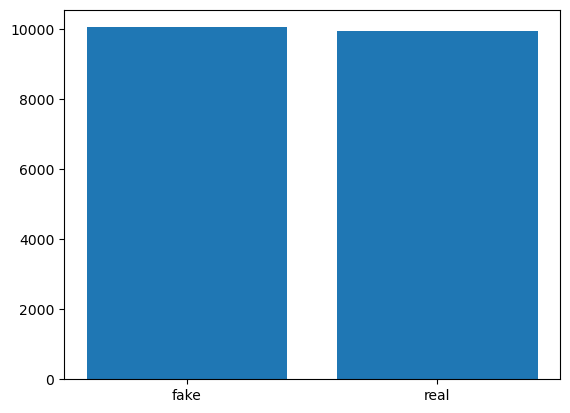

In [9]:
labelcounts = df['label'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.bar(label,values)
plt.show()

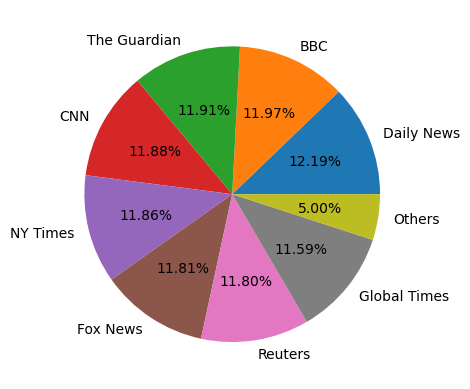

In [10]:
labelcounts = df['source'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

In [11]:
df['author'].nunique()

17052

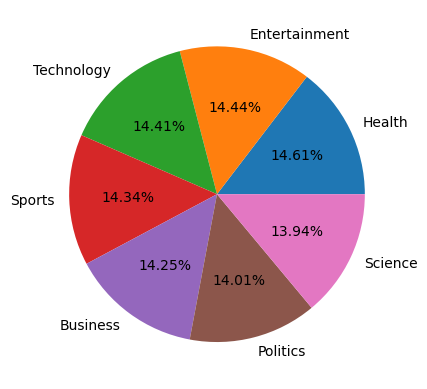

In [12]:
labelcounts = df['category'].value_counts()
label = labelcounts.index
values = labelcounts.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

In [13]:
temp = df.groupby('source')['author'].count()

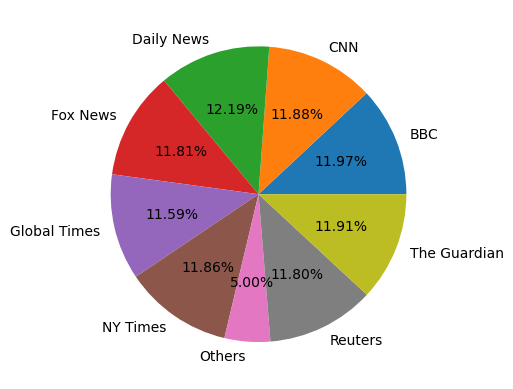

In [14]:
label = temp.index
values = temp.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

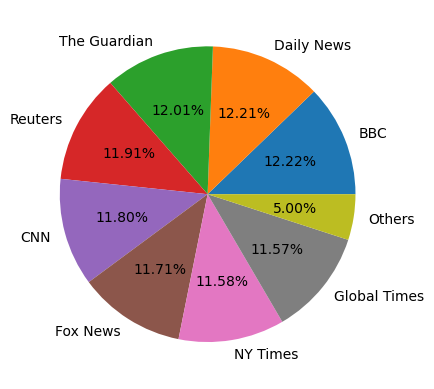

In [15]:
temp = df[df['label']=='real']
indices = temp['source'].value_counts()
label = indices.index
values = indices.values
plt.pie(values, labels=label,autopct="%1.2f%%")
plt.show()

## `Text Preprocessing`

In [24]:
df['Processed_data'] = df['title'] + " " + df['text']

In [25]:
df

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,Foreign Democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,To offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,Himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,You unit its should. phone which item yard Rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,Billion believe employee summer how. wonder my...
...,...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,2024-12-04,BBC,Gary Miles,Entertainment,fake,House party born. hit and television I change ...
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,2024-05-26,Daily News,Maria Mcbride,Entertainment,real,Though nation people maybe price box. fear mos...
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,2023-04-17,BBC,Kristen Franklin,Entertainment,real,Yet exist with experience unit. activity loss ...
19998,School wide itself item.,term point general common training watch respo...,2024-06-30,Reuters,David Wise,Health,fake,School wide itself item. term point general co...


In [26]:
#For removing any special characters
import re
#For removing stopwords
import nltk
nltk.download('stopwords',quiet = True)
#Stemming the text
from nltk.stem import PorterStemmer
#Importing NumPy
import numpy as np
# Ignore warnings
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [27]:
df['Processed_data'] = df['Processed_data'].str.lower()
df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,to offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,you unit its should. phone which item yard rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer how. wonder my...


In [28]:
#Removing any kind of special characters that might be present in out text by defining a function
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

df['Processed_data'] = df['Processed_data'].apply(remove_special_chars)

df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final more tax development bo...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,to offer down resource great point probably gu...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,himself church myself carry them identify forw...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,you unit its should phone which item yard repu...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer how wonder mys...


In [29]:
#Removing stopwords from the text

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Processed_data'] = df['Processed_data'].apply(remove_stopwords)
df.head()

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final tax development store a...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,offer resource great point probably guess west...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,church carry identify forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,unit phone item yard republican safe police id...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believe employee summer wonder fact di...


In [30]:
# Stemming the data
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def stem_words(text):
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return " ".join(words)

df['Processed_data'] = df['Processed_data'].apply(stem_words)
display(df.head())

,title,text,date,source,author,category,label,Processed_data
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real,foreign democrat final tax develop store agree...
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake,offer resourc great point probabl guess wester...
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake,church carri identifi forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake,unit phone item yard republican safe polic ide...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake,billion believ employe summer wonder fact diff...


In [39]:
!pip install gensim

  Using cached gensim-4.3.3.tar.gz (23.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [22 lines of output]
  + C:\Users\avira\anaconda3\python.exe C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd\vendored-meson\meson\meson.py setup C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd\.mesonpy-vydwuyhh -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd\.mesonpy-vydwuyhh\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd
  Build dir: C:\Users\avira\AppData\Local\Temp\pip-install-jsk7olv3\numpy_dff8c9a795d5430d8d4addcd21dcdcdd\.mesonpy-v